In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt


In [5]:
path = "otolith_annotations.csv"

df = pd.read_csv(path)
df.head()



,image_id,annotator,age,previous_age,uncertain,is_issue,timestamp,comments,unusable,cruise,station_nr,individual_id
0,24320290.jpg,petrun,4,4,False,False,2026-05-04T08:37:53.959756+00:00,NaN,NaN,NaN,NaN,NaN
1,24600950.jpg,petrun,10,10,False,True,2026-05-04T08:38:24.829777+00:00,NaN,NaN,NaN,NaN,NaN
2,24910773.jpg,petrun,4,4,False,False,2026-05-04T08:38:39.333086+00:00,NaN,NaN,NaN,NaN,NaN
3,24409451.jpg,petrun,10,10,False,True,2026-05-04T08:39:03.488486+00:00,NaN,NaN,NaN,NaN,NaN
4,24879560.jpg,petrun,5,4,False,True,2026-05-04T08:39:21.563967+00:00,NaN,NaN,NaN,NaN,NaN


In [6]:
df_issue = df[df["is_issue"] == True]
df_not_issue = df[df["is_issue"] == False]



## Q1: Is there a variation of age difference between `age` and `previous_age` according to `is_issue`?

/var/folders/yy/91yd99zj55qfx3v8d5xn2htm0000gp/T/ipykernel_9414/3917921358.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(data_box, labels=["Not Issue", "Issue"], patch_artist=True)


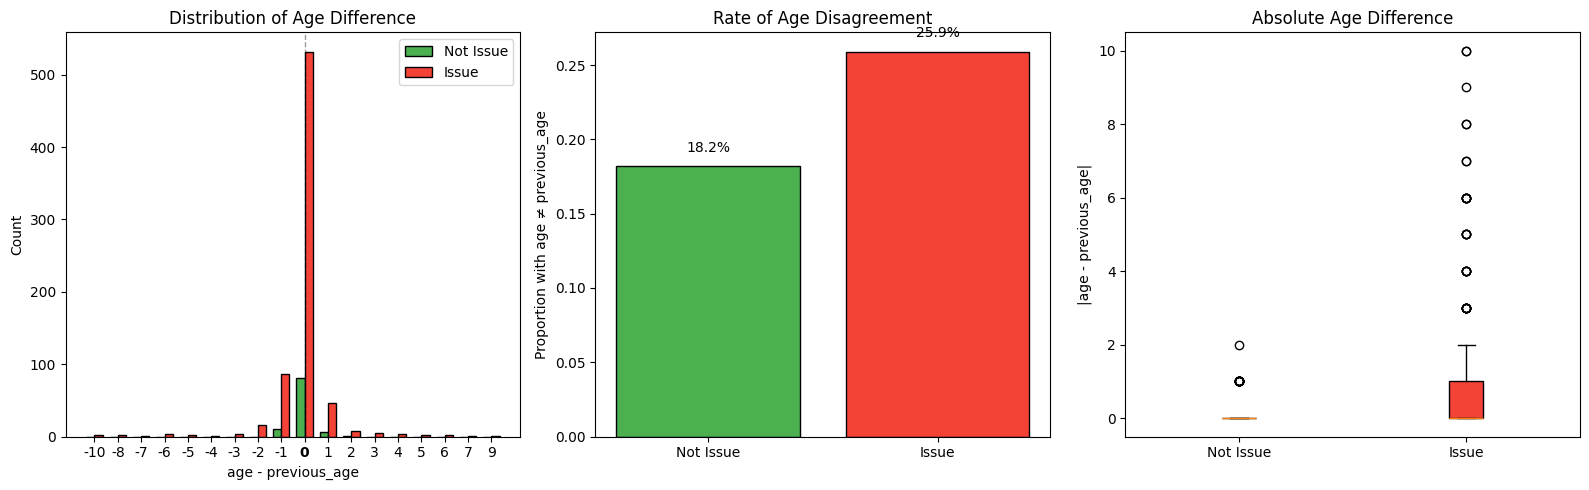

         age_diff                                       abs_age_diff        \
            count  mean   std   min  25%  50%  75%  max        count  mean   
is_issue                                                                     
False        99.0 -0.03  0.46  -1.0  0.0  0.0  0.0  2.0         99.0  0.19   
True        718.0 -0.11  1.29 -10.0  0.0  0.0  0.0  9.0        718.0  0.47   

                                          
           std  min  25%  50%  75%   max  
is_issue                                  
False     0.42  0.0  0.0  0.0  0.0   2.0  
True      1.21  0.0  0.0  0.0  1.0  10.0  


In [7]:
df["age_diff"] = df["age"] - df["previous_age"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Distribution of age_diff by is_issue — discrete bar chart
all_diffs = sorted(df["age_diff"].unique())
x_pos = np.arange(len(all_diffs))
width = 0.35

counts_not_issue = df.loc[df["is_issue"] == False, "age_diff"].value_counts().reindex(all_diffs, fill_value=0)
counts_issue = df.loc[df["is_issue"] == True, "age_diff"].value_counts().reindex(all_diffs, fill_value=0)

axes[0].bar(x_pos - width/2, counts_not_issue.values, width, label="Not Issue", color="#4CAF50", edgecolor="black")
axes[0].bar(x_pos + width/2, counts_issue.values, width, label="Issue", color="#F44336", edgecolor="black")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([str(d) for d in all_diffs])
# highlight zero
zero_idx = all_diffs.index(0)
axes[0].get_xticklabels()[zero_idx].set_fontweight("bold")
axes[0].axvline(zero_idx, color="black", linestyle="--", linewidth=1, alpha=0.4)
axes[0].set_xlabel("age - previous_age")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Age Difference")
axes[0].legend()

# 2) Proportion with age_diff != 0
props = df.groupby("is_issue")["age_diff"].apply(lambda x: (x != 0).mean())
bars = axes[1].bar(["Not Issue", "Issue"], props.values, color=["#4CAF50", "#F44336"], edgecolor="black")
axes[1].set_ylabel("Proportion with age ≠ previous_age")
axes[1].set_title("Rate of Age Disagreement")
for bar, val in zip(bars, props.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"{val:.1%}", ha="center")

# 3) Box plot of absolute age_diff
df["abs_age_diff"] = df["age_diff"].abs()
data_box = [df.loc[df["is_issue"] == False, "abs_age_diff"], df.loc[df["is_issue"] == True, "abs_age_diff"]]
bp = axes[2].boxplot(data_box, labels=["Not Issue", "Issue"], patch_artist=True)
bp["boxes"][0].set_facecolor("#4CAF50")
bp["boxes"][1].set_facecolor("#F44336")
axes[2].set_ylabel("|age - previous_age|")
axes[2].set_title("Absolute Age Difference")

plt.tight_layout()
plt.show()

# Summary stats
print(df.groupby("is_issue")[["age_diff", "abs_age_diff"]].describe().round(2))

## Further questions to consider

- **Q2: Does `uncertain` correlate with `is_issue`?** Are samples flagged as uncertain by the annotator also more likely to be flagged by cleanlab?
- **Q3: Is cleanlab flagging concentrated at certain ages?** Are issues more common at higher ages (harder to read) or evenly distributed?
- **Q4: Direction of age change** — When reviewers disagree with `previous_age`, do they tend to revise up or down? Does this differ for issue vs non-issue?
- **Q5: Per-annotator patterns** — Does one annotator contribute disproportionately to flagged issues?
- **Q6: Are `unusable` samples enriched among issues?** Do cleanlab-flagged samples have a higher rate of being marked unusable during review?

Does age difference correlate with model confidence? 
